In [3]:
#Cell 0 — Imports & global paths
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

In [4]:
ds_p1 = xr.open_dataset("/Users/luty8/MHW_Project/data/interim/event_p1_terms_1993_2023.nc")
df_p1 = ds_p1.to_dataframe().reset_index()

In [5]:
df_p1_use = df_p1.copy()

# Closure residual (K): obs minus Qnet-only
df_p1_use["resid_K"] = df_p1_use["dSST_obs_K"] - df_p1_use["deltaT_Qnet_K"]

# Also store ratio for diagnostics (avoid divide-by-zero)
df_p1_use["ratio_dT_over_dSST"] = df_p1_use["deltaT_Qnet_K"] / df_p1_use["dSST_obs_K"].replace(0, np.nan)

#df_p1_use.to_parquet(OUTDIR / "event_table_P1.parquet", index=False)
df_p1_use.head()

,event_id,cluster,t_start,t_peak,onset_days,dSST_obs_K,deltaT_Qnet_K,dTdt_obs_K_per_day,dTdt_Qnet_K_per_day,mld_mean_m,resid_K,ratio_dT_over_dSST
0,35,0,1993-01-04,1993-01-16,13,0.360995,1.538738,0.027769,0.118364,19.797682,-1.177743,4.262488
1,36,3,1993-07-29,1993-07-30,2,0.120265,0.125602,0.060132,0.062801,10.904949,-0.005337,1.044378
2,37,0,1994-05-07,1994-05-11,5,0.390277,0.270092,0.078055,0.054018,11.207365,0.120185,0.692053
3,38,1,1994-11-08,1994-11-10,3,0.188330,0.263612,0.062777,0.087871,22.034781,-0.075281,1.399730
4,39,0,1995-05-11,1995-05-15,5,0.372834,0.558397,0.074567,0.111679,11.405018,-0.185563,1.497711


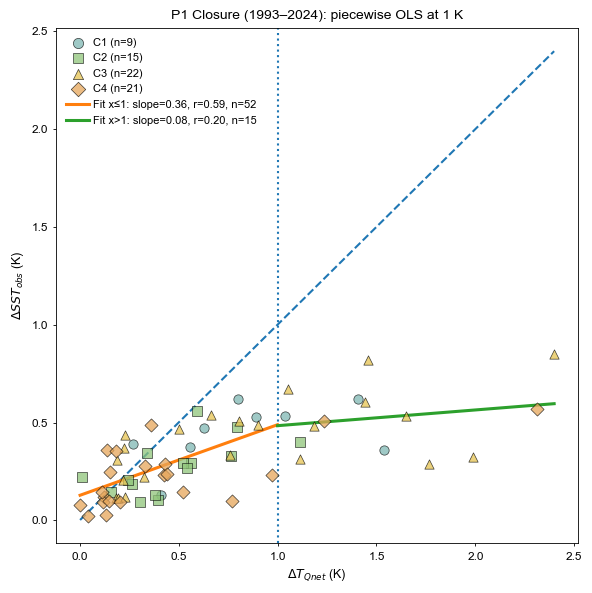

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = df_p1_use["deltaT_Qnet_K"].to_numpy()
y = df_p1_use["dSST_obs_K"].to_numpy()
m = np.isfinite(x) & np.isfinite(y)

# -------- split masks by threshold (1 K) --------
thr = 1
m_lo = m & (x <= thr)
m_hi = m & (x >  thr)

def fit_line(xv, yv, mask):
    n = int(mask.sum())
    if n >= 2:
        a, b = np.polyfit(xv[mask], yv[mask], 1)
        r = np.corrcoef(xv[mask], yv[mask])[0, 1]
        return a, b, r, n
    else:
        return np.nan, np.nan, np.nan, n

a_lo, b_lo, r_lo, n_lo = fit_line(x, y, m_lo)
a_hi, b_hi, r_hi, n_hi = fit_line(x, y, m_hi)

# -------- colors: keep your C1–C4 palette but show points by cluster --------
cluster_colors = [
    "#7fb8b3",  # C1
    "#8fc57a",  # C2
    "#e6c451",  # C3
    "#e6a65a",  # C4
]
markers = ["o", "s", "^", "D"]  # helps separate C3/C4 without changing colors

fig, ax = plt.subplots(figsize=(6, 6))

for cl in sorted(df_p1_use["cluster"].unique()):  # cl assumed 0..3
    sub = df_p1_use[df_p1_use["cluster"] == cl]
    ax.scatter(
        sub["deltaT_Qnet_K"], sub["dSST_obs_K"],
        s=45, alpha=0.75,
        marker=markers[cl],
        color=cluster_colors[cl],
        edgecolor="k", linewidth=0.5,
        label=f"C{cl+1} (n={len(sub)})",
        zorder=3
    )

# 1:1 line
xmin = np.nanmin(x[m]); xmax = np.nanmax(x[m])
xx = np.linspace(xmin, xmax, 200)
ax.plot(xx, xx, linestyle="--", linewidth=1.5, zorder=1)

# threshold line at x=1 K
ax.axvline(thr, linestyle=":", linewidth=1.5, zorder=1)

# piecewise regression lines
if np.isfinite(a_lo):
    xx_lo = np.linspace(xmin, min(thr, xmax), 100)
    ax.plot(xx_lo, a_lo * xx_lo + b_lo, linewidth=2.2, zorder=2,
            label=f"Fit x≤{thr:g}: slope={a_lo:.2f}, r={r_lo:.2f}, n={n_lo}")
if np.isfinite(a_hi):
    xx_hi = np.linspace(max(thr, xmin), xmax, 100)
    ax.plot(xx_hi, a_hi * xx_hi + b_hi, linewidth=2.2, zorder=2,
            label=f"Fit x>{thr:g}: slope={a_hi:.2f}, r={r_hi:.2f}, n={n_hi}")

ax.set_xlabel(r"$\Delta T_{Qnet}$ (K)")
ax.set_ylabel(r"$\Delta SST_{obs}$ (K)")
ax.set_title("P1 Closure (1993–2024): piecewise OLS at 1 K")

ax.legend(frameon=False, markerscale=1.1, handletextpad=0.4)
plt.tight_layout()
plt.show()


In [7]:
DPI = 600
def save_fig(fig, name_base, outdir="."):
    pdf_path = f"{outdir}/{name_base}.pdf"
    png_path = f"{outdir}/{name_base}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

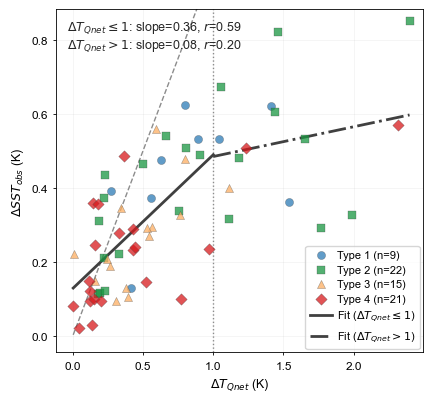

Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig14_heatflux_closure.pdf
Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig14_heatflux_closure.png


In [19]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================================================
# Journal-style settings (slightly larger for Word readability)
# ============================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# Copy and swap Type 2 / 3
# original clusters assumed 0,1,2,3
# swapped order in plotting labels:
#   old 0 -> Type 1
#   old 2 -> Type 2
#   old 1 -> Type 3
#   old 3 -> Type 4
# ============================================================
df_plot = df_p1_use.copy()

swap_map = {0: 0, 1: 2, 2: 1, 3: 3}
df_plot["cluster_plot"] = df_plot["cluster"].map(swap_map)

# ============================================================
# Data
# ============================================================
x = df_plot["deltaT_Qnet_K"].to_numpy()
y = df_plot["dSST_obs_K"].to_numpy()
m = np.isfinite(x) & np.isfinite(y)

thr = 1.0
m_lo = m & (x <= thr)
m_hi = m & (x > thr)

def fit_line(xv, yv, mask):
    n = int(mask.sum())
    if n >= 2:
        a, b = np.polyfit(xv[mask], yv[mask], 1)
        r = np.corrcoef(xv[mask], yv[mask])[0, 1]
        return a, b, r, n
    return np.nan, np.nan, np.nan, n

a_lo, b_lo, r_lo, n_lo = fit_line(x, y, m_lo)
a_hi, b_hi, r_hi, n_hi = fit_line(x, y, m_hi)

# ============================================================
# Colors and markers (consistent with previous Type figures)
# ============================================================
type_colors = [
    "#2c7bb6",  # Type 1
    "#1a9641",  # Type 2
    "#fdae61",  # Type 3
    "#d7191c",  # Type 4
]
markers = ["o", "s", "^", "D"]

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=(4.4, 4.1))

# scatter by Type
for cl_plot in [0, 1, 2, 3]:
    sub = df_plot[df_plot["cluster_plot"] == cl_plot]
    ax.scatter(
        sub["deltaT_Qnet_K"],
        sub["dSST_obs_K"],
        s=34,
        alpha=0.75,
        marker=markers[cl_plot],
        color=type_colors[cl_plot],
        edgecolor="0.25",
        linewidth=0.25,
        label=f"Type {cl_plot+1} (n={len(sub)})",
        zorder=3
    )

# reference lines
xmin = np.nanmin(x[m])
xmax = np.nanmax(x[m])
ymin = np.nanmin(y[m])
ymax = np.nanmax(y[m])

xx = np.linspace(xmin, xmax, 200)

# 1:1 line
ax.plot(
    xx, xx,
    color="0.55",
    linewidth=1.0,  
    linestyle="--",
    zorder=1
)

# threshold line x = 1 K
ax.axvline(
    thr,
    color="0.55",
    linestyle=":",
    linewidth=1.0,
    zorder=1
)

# piecewise regression lines
if np.isfinite(a_lo):
    xx_lo = np.linspace(xmin, min(thr, xmax), 100)
    ax.plot(
        xx_lo,
        a_lo * xx_lo + b_lo,
        linewidth=2.0,
        color="0.25",
        linestyle="-",
        zorder=2,
        label=fr"Fit ($\Delta T_{{Qnet}}\leq {thr:g}$)"
    )

if np.isfinite(a_hi):
    xx_hi = np.linspace(max(thr, xmin), xmax, 100)
    ax.plot(
        xx_hi,
        a_hi * xx_hi + b_hi,
        linewidth=2.0,
        color="0.25",
        linestyle="-.",
        zorder=2,
        label=fr"Fit ($\Delta T_{{Qnet}}>{thr:g}$)"
    )

# axes
ax.set_xlabel(r"$\Delta T_{Qnet}$ (K)")
ax.set_ylabel(r"$\Delta SST_{obs}$ (K)")


# limits with a little padding
xrng = xmax - xmin
yrng = ymax - ymin
ax.set_xlim(xmin - 0.05 * xrng, xmax + 0.04 * xrng)
ax.set_ylim(ymin - 0.08 * yrng, ymax + 0.04 * yrng)

# light grid
ax.grid(True, linewidth=0.4, alpha=0.22)
ax.set_axisbelow(True)

ax.text(
    0.03, 0.97,
    fr"$\Delta T_{{Qnet}}\leq {thr:g}$: slope={a_lo:.2f}, $r$={r_lo:.2f}" "\n"
    fr"$\Delta T_{{Qnet}}>{thr:g}$: slope={a_hi:.2f}, $r$={r_hi:.2f}",
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=9, color="0.15"
)
# compact legend
ax.legend(
    
    loc="lower right",
    markerscale=1.0,
    handletextpad=0.4,
    handlelength=2.0,
    borderaxespad=0.3,
    labelspacing=0.4
)

plt.tight_layout()
plt.show()

save_fig(fig, "Fig14_heatflux_closure", outdir="/Users/luty8/Documents/TAMU/agu25/fig")
# save
#fig.savefig(
#    "/Users/luty8/Documents/TAMU/agu25/P1_closure_piecewise_OLS_journal.png",
#    dpi=600,
#    bbox_inches="tight",
#    facecolor="white"
#)